# Qiskit 基础调用与使用指南（中文）

这个 notebook 面向第一次接触 Qiskit 的同学，目标是：

- 认识 Qiskit 的核心对象和最常见调用链路
- 学会本地模拟器上的基本运行方式
- 通过几个可执行案例快速上手

本文默认使用本地模拟器 `AerSimulator`，因此不依赖 IBM Quantum 账号，也不需要连接真实量子硬件。

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import math
import numpy as np
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)

Qiskit version: 2.2.3
Qiskit Aer version: 0.17.2


## 1. Qiskit 的最小工作流

平时最常见的调用顺序可以概括为：

1. 用 `QuantumCircuit` 创建量子线路
2. 添加量子门，例如 `h`、`x`、`cx`、`ry`
3. 添加测量，把量子比特映射到经典比特
4. 选择后端，这里用本地模拟器 `AerSimulator`
5. 用 `transpile(...)` 按后端要求编译线路
6. 用 `backend.run(...)` 执行，并从结果对象里取出 `counts`

如果你只是想看“测量前的理论量子态”，可以直接用 `Statevector.from_instruction(...)`，这时通常不要先加测量门。

In [2]:
def run_counts(circuit, shots=1024, seed=42):
    backend = AerSimulator(seed_simulator=seed)
    compiled = transpile(circuit, backend)
    result = backend.run(compiled, shots=shots).result()
    counts = result.get_counts()
    return compiled, counts

## 2. 案例一：单量子比特叠加态

下面这条线路的逻辑很简单：

- 初始态默认是 `|0>`
- `H` 门把它变成叠加态
- 测量后通常会接近 `0` 和 `1` 各占一半

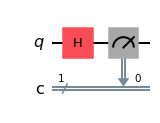

编译后线路深度: 2
测量结果: {'1': 498, '0': 526}


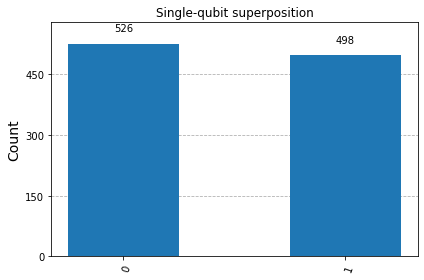

In [3]:
qc1 = QuantumCircuit(1, 1)
qc1.h(0)
qc1.measure(0, 0)

fig = qc1.draw(output="mpl")
display(fig)
plt.close(fig)

compiled1, counts1 = run_counts(qc1, shots=1024)
print("编译后线路深度:", compiled1.depth())
print("测量结果:", counts1)

fig = plot_histogram(counts1, title="Single-qubit superposition")
display(fig)
plt.close(fig)

`counts` 是最常见的结果格式，本质上是“比特串 -> 出现次数”的字典。对于这个例子，`'0'` 和 `'1'` 的次数应该都比较接近 `shots / 2`。

## 3. 案例二：Bell 态与纠缠

Bell 态是量子计算里非常经典的纠缠态例子。下面的线路：

- 先对第 0 个量子比特施加 `H`
- 再施加 `CX(0, 1)`
- 最终得到接近 `( |00> + |11> ) / sqrt(2)` 的状态

测量时，结果通常主要集中在 `00` 和 `11`，这正是纠缠的典型表现。

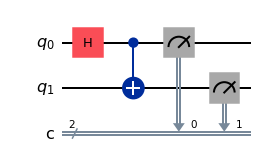

编译后线路深度: 3
测量结果: {'11': 1047, '00': 1001}


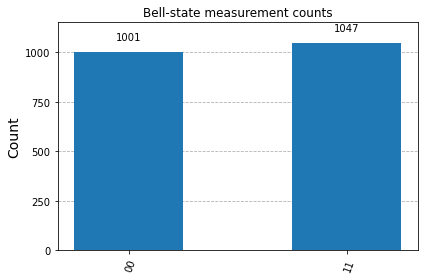

In [4]:
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])

fig = bell.draw(output="mpl")
display(fig)
plt.close(fig)

compiled_bell, bell_counts = run_counts(bell, shots=2048)
print("编译后线路深度:", compiled_bell.depth())
print("测量结果:", bell_counts)

fig = plot_histogram(bell_counts, title="Bell-state measurement counts")
display(fig)
plt.close(fig)

## 4. 案例三：直接查看测量前的量子态

有时候我们并不关心测量后的采样次数，而是想直接看理论上的量子态。这时可以使用 `Statevector`。

注意：

- `Statevector` 适合分析“未测量”的纯量子线路
- 如果线路已经加入测量门，通常应该先去掉测量，再计算态向量

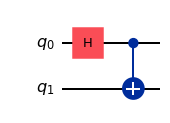

态向量:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

概率分布:
{'00': 0.4999999999999999, '11': 0.4999999999999999}


In [5]:
bell_no_measure = QuantumCircuit(2)
bell_no_measure.h(0)
bell_no_measure.cx(0, 1)

fig = bell_no_measure.draw(output="mpl")
display(fig)
plt.close(fig)

bell_state = Statevector.from_instruction(bell_no_measure)
print("态向量:")
print(bell_state)
print()
print("概率分布:")
print(bell_state.probabilities_dict())

从上面的概率分布里，你会看到 `00` 和 `11` 的概率都接近 `0.5`，而 `01`、`10` 接近 `0`。

## 5. 案例四：参数化量子线路

Qiskit 支持把量子门中的角度写成参数，之后再批量赋值。这个模式很适合：

- 做参数扫描
- 做量子机器学习中的变分线路
- 做不同超参数下的实验对比

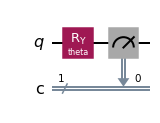

In [6]:
theta = Parameter("theta")

param_circuit = QuantumCircuit(1, 1)
param_circuit.ry(theta, 0)
param_circuit.measure(0, 0)

fig = param_circuit.draw(output="mpl")
display(fig)
plt.close(fig)

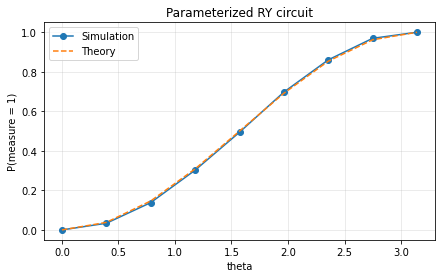

theta = 0.000, simulated P(1) = 0.0000
theta = 0.393, simulated P(1) = 0.0337
theta = 0.785, simulated P(1) = 0.1382
theta = 1.178, simulated P(1) = 0.3022
theta = 1.571, simulated P(1) = 0.4941
theta = 1.963, simulated P(1) = 0.6973
theta = 2.356, simulated P(1) = 0.8604
theta = 2.749, simulated P(1) = 0.9692
theta = 3.142, simulated P(1) = 1.0000


In [7]:
angles = np.linspace(0, math.pi, 9)
p1_sim = []
p1_theory = []

for angle in angles:
    bound = param_circuit.assign_parameters({theta: angle})
    _, counts = run_counts(bound, shots=2048)
    p1 = counts.get("1", 0) / 2048
    p1_sim.append(p1)
    p1_theory.append(math.sin(angle / 2) ** 2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(angles, p1_sim, "o-", label="Simulation")
ax.plot(angles, p1_theory, "--", label="Theory")
ax.set_xlabel("theta")
ax.set_ylabel("P(measure = 1)")
ax.set_title("Parameterized RY circuit")
ax.legend()
ax.grid(alpha=0.3)
display(fig)
plt.close(fig)

for angle, p1 in zip(angles, p1_sim):
    print(f"theta = {angle:.3f}, simulated P(1) = {p1:.4f}")

这个例子里，`RY(theta)` 作用在 `|0>` 上之后，测到 `1` 的理论概率是：

`sin^2(theta / 2)`

所以仿真结果会随着 `theta` 从 `0` 到 `pi` 增大而逐渐从 `0` 上升到 `1`。

## 6. 常用 API 速查

下面这些接口是初学阶段最常用的：

- 创建线路：`QuantumCircuit(n_qubits, n_clbits)`
- 单比特门：`h`、`x`、`y`、`z`、`rx`、`ry`、`rz`
- 双比特门：`cx`、`cz`、`swap`
- 测量：`measure(q, c)`、`measure([..], [..])`、`measure_all()`
- 编译：`transpile(circuit, backend)`
- 运行：`backend.run(compiled_circuit, shots=...)`
- 读取采样结果：`result.get_counts()`
- 读取理论态：`Statevector.from_instruction(circuit)`
- 参数绑定：`circuit.assign_parameters({...})`